# Ejercicio 1 — Clasificación de ACV con redes MLP

## 1. Preparación del entorno

### 1.1. Bibliotecas y reproducibilidad

Se define `SEED = 42` como única semilla del trabajo. Se utiliza en la partición, el sobremuestreo y los entrenamientos. Se reinicia la misma semilla antes de cada modelo para que su ejecución no dependa de los experimentos anteriores; no se prueban semillas alternativas.


In [99]:
import random
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

# Semilla común para la partición y todos los experimentos.
SEED = 42


def fijar_semilla(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


fijar_semilla()


## 2. Datos e inspección inicial

### 2.1. Obtención del dataset


In [100]:
url = "https://drive.google.com/file/d/1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ/view?usp=drive_link"
zip_filename = "dataset.zip"
extract_dir = "./dataset_extraido"

gdown.download(url, zip_filename, quiet=False)

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Archivo descomprimido con éxito en: {extract_dir}")

ruta_csv = os.path.join("./dataset_extraido/healthcare-dataset-stroke-data.csv")
df = pd.read_csv(ruta_csv)
df_copia = df.copy()  # copia de resguardo del df original

Downloading...
From: https://drive.google.com/uc?id=1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ
To: c:\Users\Gabi\Proyectos\AA2_TP1\dataset.zip
100%|██████████| 69.0k/69.0k [00:00<00:00, 1.46MB/s]

Archivo descomprimido con éxito en: ./dataset_extraido


### 2.2. Variables e inspección general


| Columna | Tipo de dato | Descripción | Valores / Rango |
| :--- | :--- | :--- | :--- |
| **id** | Entero (ID) | Identificador único del paciente | Número entero de identificación |
| **gender** | Categórico | Género del paciente | `"Male"`, `"Female"`, `"Other"` |
| **age** | Numérico (Continuo) | Edad del paciente en años | Número flotante o entero |
| **hypertension** | Binario (Nominal) | Presencia de hipertensión arterial previa | `0` = No, `1` = Sí |
| **heart_disease** | Binario (Nominal) | Presencia de enfermedad cardíaca previa | `0` = No, `1` = Sí |
| **ever_married** | Categórico | Indica si el paciente ha estado casado alguna vez | `"Yes"`, `"No"` |
| **work_type** | Categórico | Tipo de ocupación o relación laboral | `"Private"`, `"Self-employed"`, `"Govt_job"`, `"children"`, `"Never_worked"` |
| **Residence_type** | Categórico | Tipo de zona de residencia | `"Urban"`, `"Rural"` |
| **avg_glucose_level** | Numérico (Continuo) | Nivel promedio de glucosa en sangre (mg/dL) | Número flotante |
| **bmi** | Numérico (Continuo) | Índice de masa corporal ($\text{kg/m}^2$) | Número flotante (contiene valores nulos / `"N/A"`) |
| **smoking_status** | Categórico | Estado actual o histórico de consumo de tabaco | `"formerly smoked"`, `"never smoked"`, `"smokes"`, `"Unknown"` |
| **stroke** | Binario (Target) | Indica si el paciente sufrió un accidente cerebrovascular | `0` = No, `1` = Sí |

In [101]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [103]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [104]:
total_duplicados = df.duplicated().sum()
print(f"Total de filas completas duplicadas: {total_duplicados}")

ids_duplicados = df.duplicated(subset=["id"]).sum()
print(f"Total de IDs duplicados: {ids_duplicados}")

Total de filas completas duplicadas: 0
Total de IDs duplicados: 0


In [105]:
print(
    pd.DataFrame(
        {
            "Total_Nulos": df.isnull().sum(),
            "Porcentaje_%": (df.isnull().sum() / len(df)) * 100,
        }
    )
)

                   Total_Nulos  Porcentaje_%
id                           0      0.000000
gender                       0      0.000000
age                          0      0.000000
hypertension                 0      0.000000
heart_disease                0      0.000000
ever_married                 0      0.000000
work_type                    0      0.000000
Residence_type               0      0.000000
avg_glucose_level            0      0.000000
bmi                        201      3.933464
smoking_status               0      0.000000
stroke                       0      0.000000


> **Pendiente de desarrollo:** Interpretar en conjunto la inspección inicial: dimensiones, tipos de variables, estadísticos, duplicados y datos faltantes.


### 2.3. Distribución de la variable objetivo

Se representan las cantidades y proporciones de las clases de `stroke` en el dataset original, antes de la partición y del tratamiento del desbalance.


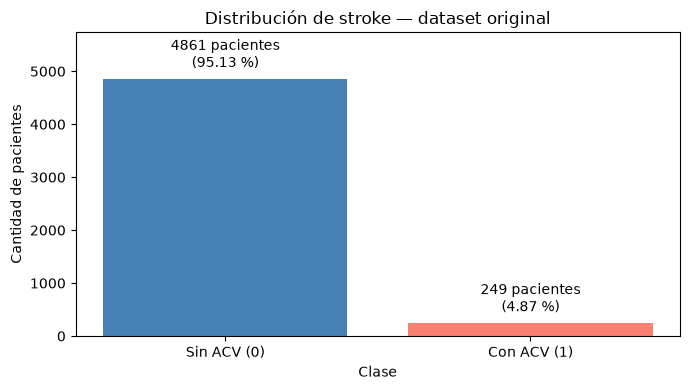

In [106]:
conteos_stroke = df["stroke"].value_counts().reindex([0, 1], fill_value=0)
porcentajes_stroke = 100 * conteos_stroke / conteos_stroke.sum()

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    ["Sin ACV (0)", "Con ACV (1)"],
    conteos_stroke.to_numpy(),
    color=["steelblue", "salmon"],
)
for barra, cantidad, porcentaje in zip(barras, conteos_stroke, porcentajes_stroke):
    ax.annotate(
        f"{cantidad} pacientes\n({porcentaje:.2f} %)",
        xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
        xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
    )
ax.set_title("Distribución de stroke — dataset original")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de pacientes")
ax.set_ylim(0, conteos_stroke.max() * 1.18)
plt.tight_layout()
plt.show()


Se observa un marcado desbalance: 4861 pacientes sin ACV (95.13 %) y 249 con ACV (4.87 %). La clase negativa es aproximadamente 19.5 veces más frecuente. Una predicción siempre negativa alcanzaría una accuracy de 95.13 %, pero no detectaría ningún caso positivo; por ello, se considera necesario evaluar recall, precisión y F2 junto con accuracy.


## 3. Partición e imputación de datos faltantes

### 3.1. Separación de train, validación y test


In [107]:
X = df.drop(columns=["stroke", "id"])
y = df["stroke"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val
)

print(f"Dimensiones de X_train: {X_train.shape} ({len(X_train) / len(df):.0%})")
print(f"Dimensiones de X_val:   {X_val.shape} ({len(X_val) / len(df):.0%})")
print(f"Dimensiones de X_test:  {X_test.shape} ({len(X_test) / len(df):.0%})")

print("\n--- Distribución de 'stroke' (Proporción %) ---")
print(f"Original: \n{y.value_counts(normalize=True).round(4)}")
print(f"Train:    \n{y_train.value_counts(normalize=True).round(4)}")
print(f"Val:      \n{y_val.value_counts(normalize=True).round(4)}")
print(f"Test:     \n{y_test.value_counts(normalize=True).round(4)}")

Dimensiones de X_train: (3066, 10) (60%)
Dimensiones de X_val:   (1022, 10) (20%)
Dimensiones de X_test:  (1022, 10) (20%)

--- Distribución de 'stroke' (Proporción %) ---
Original: 
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64
Train:    
stroke
0    0.9514
1    0.0486
Name: proportion, dtype: float64
Val:      
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64
Test:     
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64


> **Pendiente de desarrollo:** Justificar las proporciones de la partición estratificada y la exclusión de `id`; explicar el papel de train, validación y test.


### 3.2. Imputación de BMI

#### 3.2.1. Cálculo de medianas con train


In [108]:
bins = [0, 20, 40, 60, 80, 100]
labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]

# Se preserva train antes de completar los faltantes.
X_train_antes = X_train.copy()
mask_imputados = X_train_antes["bmi"].isna()

# Se obtienen las medianas a partir del BMI observado en train.
X_train_grupos = X_train_antes.copy()
X_train_grupos["age_group"] = pd.cut(
    X_train_grupos["age"], bins=bins, labels=labels, right=False, include_lowest=True
)

bmi_medians = X_train_grupos.groupby(["age_group", "gender"], observed=True)[
    "bmi"
].median()
bmi_global = X_train_antes["bmi"].median()


> **Pendiente de desarrollo:** Justificar la mediana por edad y género y el respaldo global aprendido en train; distinguir el respaldo descriptivo de una comparación predictiva entre imputaciones.


#### 3.2.2. Verificación de las medianas por grupo

Se calcula la cantidad de BMI observados y faltantes, la mediana y el rango intercuartílico por edad y género. Se señalan los grupos con menos de 10 observaciones como advertencia exploratoria; ese valor no constituye un criterio estadístico de suficiencia. Se verifica la disponibilidad de medianas para los faltantes de train y validación, sin aprender parámetros de validación.


In [109]:
# BMI original por rango de edad y género
resumen_bmi = X_train_grupos.groupby(
    ["age_group", "gender"], observed=True, dropna=False
)["bmi"].agg(
    pacientes="size",
    observados="count",
    mediana="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
)
resumen_bmi["faltantes"] = resumen_bmi["pacientes"] - resumen_bmi["observados"]
resumen_bmi["faltantes_pct"] = 100 * resumen_bmi["faltantes"] / resumen_bmi["pacientes"]
resumen_bmi["iqr"] = resumen_bmi["q3"] - resumen_bmi["q1"]
resumen_bmi["diferencia_mediana_global"] = resumen_bmi["mediana"] - bmi_global
resumen_bmi["pocas_observaciones"] = resumen_bmi["observados"] < 10
resumen_bmi = resumen_bmi[
    [
        "pacientes",
        "observados",
        "faltantes",
        "faltantes_pct",
        "mediana",
        "iqr",
        "diferencia_mediana_global",
        "pocas_observaciones",
    ]
]
display(resumen_bmi.round(2))

print(f"Mediana global observada de train: {bmi_global:.2f}")
print(
    f"Grupos con menos de 10 BMI observados: {int(resumen_bmi['pocas_observaciones'].sum())}"
)
print(f"Grupos sin BMI observado: {int(resumen_bmi['observados'].eq(0).sum())}")

# Se comprueba si los faltantes tienen una mediana de grupo disponible.
for nombre, datos in [("Train", X_train_antes), ("Validación", X_val)]:
    grupos = pd.cut(
        datos["age"], bins=bins, labels=labels, right=False, include_lowest=True
    )
    claves = pd.MultiIndex.from_arrays(
        [grupos, datos["gender"]], names=["age_group", "gender"]
    )
    medianas_disponibles = pd.Series(
        claves.map(bmi_medians).to_numpy(), index=datos.index
    )
    faltantes = datos["bmi"].isna()
    usa_respaldo = faltantes & medianas_disponibles.isna()
    print(
        f"{nombre}: {int(faltantes.sum())} BMI faltantes; "
        f"{int(usa_respaldo.sum())} requieren mediana global."
    )


pacientes  observados  faltantes  faltantes_pct  mediana  \
age_group gender                                                             
0-20      Female        285         278          7           2.46    20.60   
          Male          279         270          9           3.23    20.00   
20-40     Female        492         481         11           2.24    27.60   
          Male          238         225         13           5.46    28.80   
          Other           1           1          0           0.00    22.40   
40-60     Female        555         542         13           2.34    30.10   
          Male          384         364         20           5.21    31.05   
60-80     Female        422         395         27           6.40    29.70   
          Male          304         268         36          11.84    29.50   
80-100    Female         69          66          3           4.35    27.10   
          Male           37          37          0           0.00    28.70   

                    iqr  diferencia_mediana_global  pocas_observaciones  
age_group gender                                                         
0-20      Female   6.35                      -7.50                False  
          Male     5.77                      -8.10                False  
20-40     Female  10.40                      -0.50                False  
          Male     7.80                       0.70                False  
          Other    0.00                      -5.70                 True  
40-60     Female  10.48                       2.00                False  
          Male     7.95                       2.95                False  
60-80     Female   8.50                       1.60                False  
          Male     6.50                       1.40                False  
80-100    Female   8.40                      -1.00                False  
          Male     4.10                       0.60                False

Mediana global observada de train: 28.10
Grupos con menos de 10 BMI observados: 1
Grupos sin BMI observado: 0
Train: 139 BMI faltantes; 0 requieren mediana global.
Validación: 31 BMI faltantes; 0 requieren mediana global.


**Interpretación del resumen**

Se observa una mediana global de BMI de 28.10 y diferencias principalmente entre rangos etarios: las medianas se sitúan entre 20.00 y 20.60 en menores de 20 años y entre 30.10 y 31.05 en el grupo de 40–60 años. Las diferencias entre Female y Male dentro de cada rango son menores, lo que respalda descriptivamente la agrupación por edad más que la incorporación de género.

El único grupo con menos de 10 observaciones corresponde a Other (un paciente), sin BMI faltante. Todos los grupos cuentan con BMI observado, por lo que los 139 faltantes de train y los 31 de validación se pueden completar con sus medianas de grupo, sin recurrir al respaldo global. La mayor proporción de faltantes se registra en Male de 60–80 años (11.84 %).

#### 3.2.3. Distribución del BMI observado por grupo

Se visualizan las distribuciones de BMI observado por edad y género, junto con la mediana global de entrenamiento como referencia.


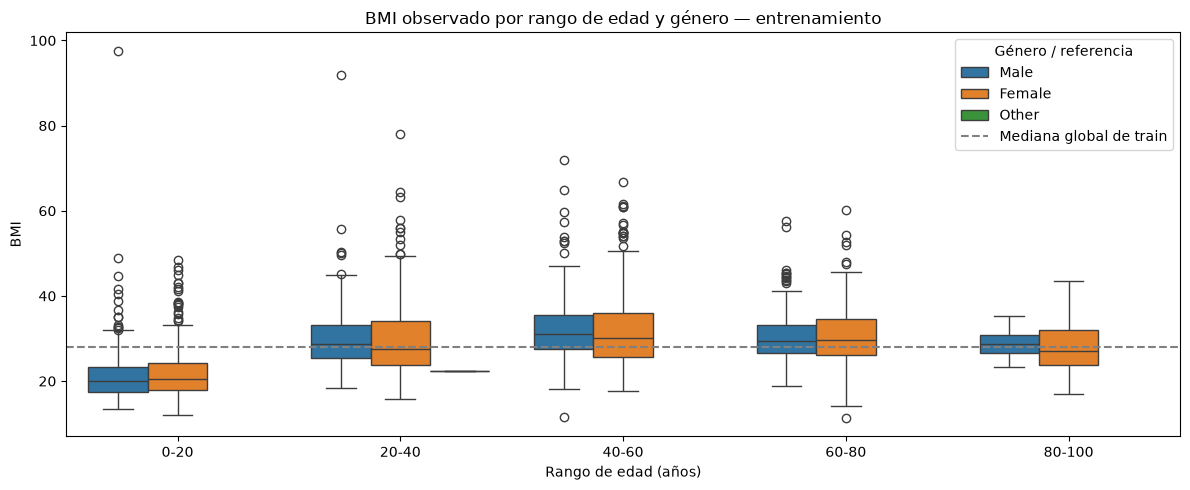

In [110]:
# Se visualizan únicamente los valores observados antes de imputar.
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=X_train_grupos.dropna(subset=["bmi"]),
    x="age_group",
    y="bmi",
    hue="gender",
    ax=ax,
)
ax.axhline(bmi_global, color="gray", linestyle="--", label="Mediana global de train")
ax.set_title("BMI observado por rango de edad y género — entrenamiento")
ax.set_xlabel("Rango de edad (años)")
ax.set_ylabel("BMI")
ax.legend(title="Género / referencia")
plt.tight_layout()
plt.show()


Se observan medianas inferiores a la referencia global (28.10) en menores de 20 años, superiores en el rango de 40–60 años y próximas a ella en los grupos de 20–40 y 80–100 años. En 60–80 años se mantienen ligeramente por encima de la referencia. Las distribuciones de Female y Male presentan un amplio solapamiento dentro de cada rango, con diferencias de mediana menores que las observadas entre edades.

Se registran valores atípicos superiores en varios grupos, lo que respalda el uso de una medida robusta como la mediana. La categoría Other se representa con una única observación y no permite caracterizar una distribución. El gráfico respalda descriptivamente la agrupación por edad, pero no demuestra una mejora predictiva de la imputación por grupos.

#### 3.2.4. Aplicación de la imputación a los tres conjuntos
Se completan los BMI faltantes con las medianas obtenidas de train, conservando los valores observados.

In [111]:
# Se aplican las mismas medianas de train a los tres conjuntos.
def imputar_bmi(df, bmi_medians, bmi_global, bins, labels):
    df = df.copy()
    df["age_group"] = pd.cut(
        df["age"], bins=bins, labels=labels, right=False, include_lowest=True
    )
    medianas = df.set_index(["age_group", "gender"]).index.map(bmi_medians)
    df["bmi"] = df["bmi"].fillna(pd.Series(medianas, index=df.index))
    df["bmi"] = df["bmi"].fillna(bmi_global)
    return df.drop(columns="age_group")


X_train = imputar_bmi(X_train_antes, bmi_medians, bmi_global, bins, labels)
X_val = imputar_bmi(X_val, bmi_medians, bmi_global, bins, labels)
X_test = imputar_bmi(X_test, bmi_medians, bmi_global, bins, labels)

print(
    f"BMI faltantes en train: {mask_imputados.sum()} antes -> {X_train['bmi'].isna().sum()} después"
)
print(
    f"BMI faltantes después: val={X_val['bmi'].isna().sum()}, test={X_test['bmi'].isna().sum()}"
)


BMI faltantes en train: 139 antes -> 0 después
BMI faltantes después: val=0, test=0


#### 3.2.5. Comparación antes y después de la imputación


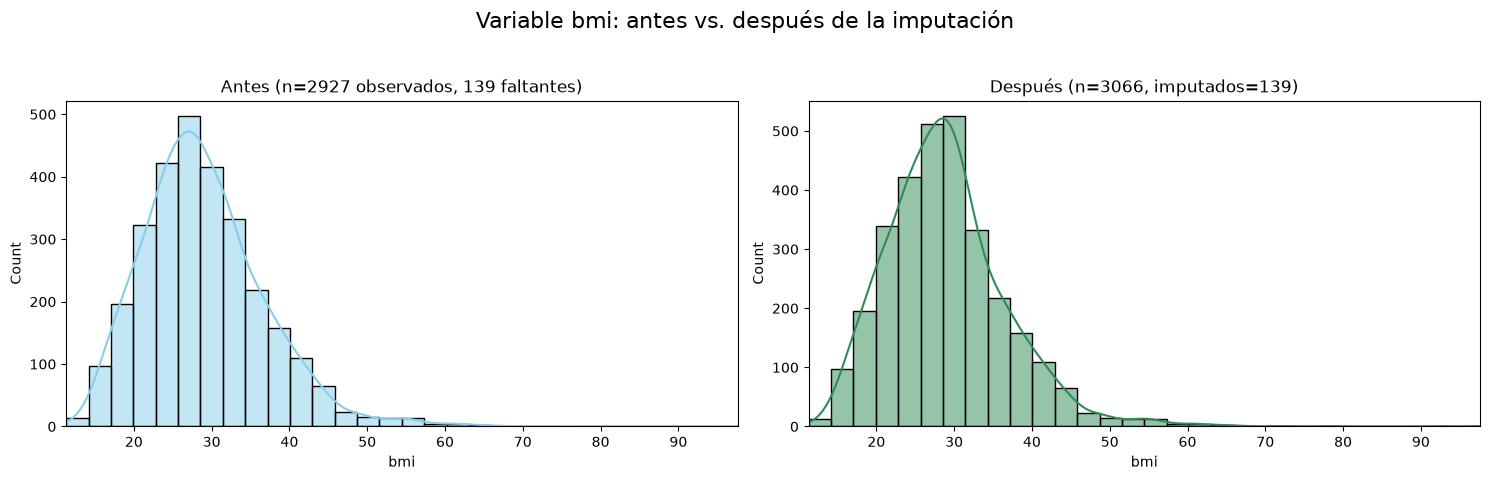

In [112]:
X_train_despues = X_train.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Variable bmi: antes vs. después de la imputación", fontsize=16)

# mismos intervalos para comparar ambas distribuciones.
xmin, xmax = X_train_despues["bmi"].min(), X_train_despues["bmi"].max()
bins_hist = np.linspace(xmin, xmax, 31)

sns.histplot(
    data=X_train_antes, x="bmi", bins=bins_hist, kde=True, ax=axes[0], color="skyblue"
)
axes[0].set_title(
    f"Antes (n={X_train_antes['bmi'].notna().sum()} observados, {mask_imputados.sum()} faltantes)"
)

sns.histplot(
    data=X_train_despues,
    x="bmi",
    bins=bins_hist,
    kde=True,
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title(
    f"Después (n={X_train_despues['bmi'].notna().sum()}, imputados={mask_imputados.sum()})"
)

for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


No se observan cambios mayores en la distribución. Se imputan 139 faltantes (4,53%)

## 4. Análisis exploratorio del conjunto de entrenamiento

### 4.1. Distribuciones numéricas y frecuencias categóricas


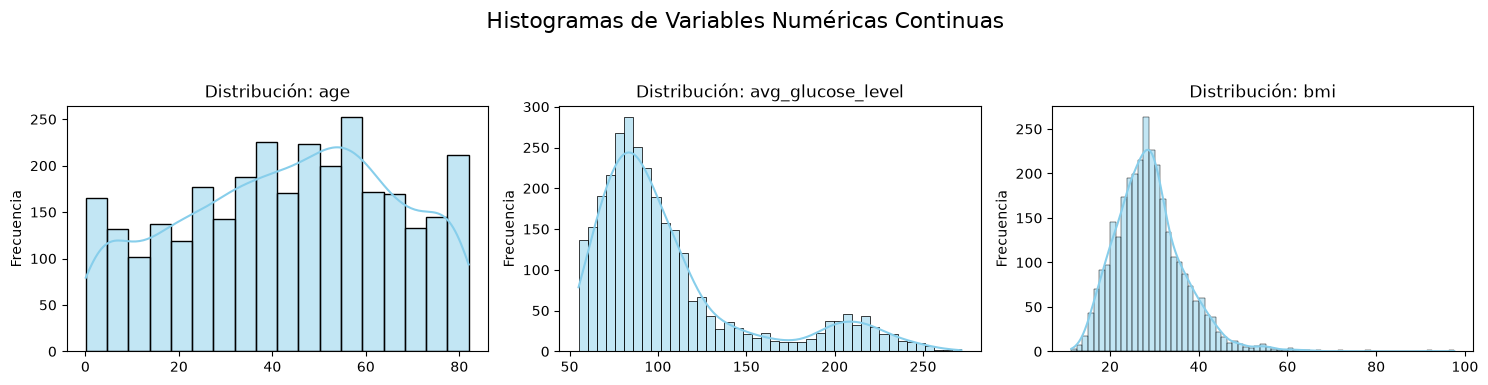

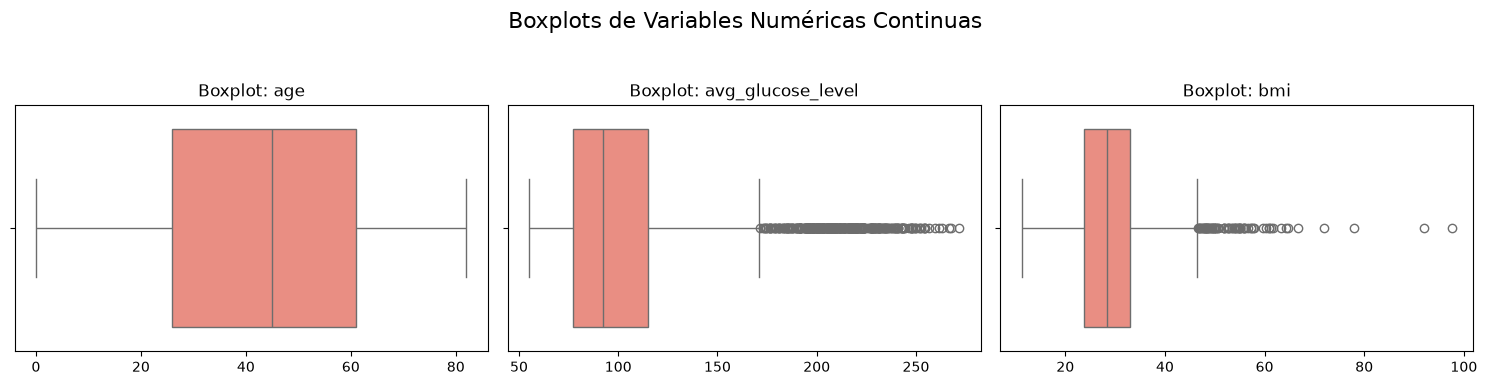

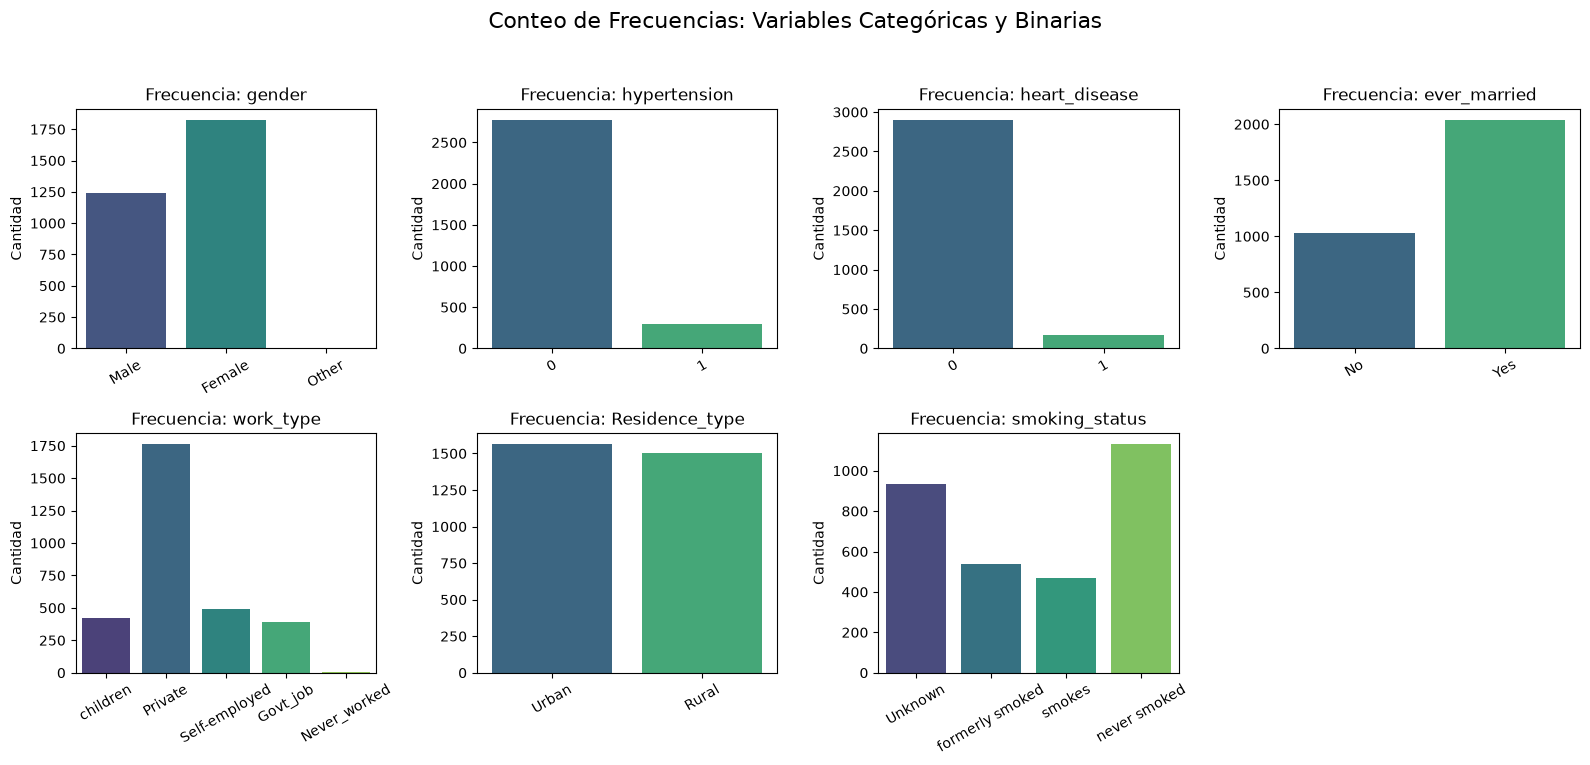

In [113]:
vars_numericas = ["age", "avg_glucose_level", "bmi"]
vars_categoricas = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

cols = 3
rows = int(np.ceil(len(vars_numericas) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle("Histogramas de Variables Numéricas Continuas", fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes_flat[i], color="skyblue")
    axes_flat[i].set_title(f"Distribución: {col}")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel("Frecuencia")

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle("Boxplots de Variables Numéricas Continuas", fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.boxplot(data=X_train, x=col, ax=axes_flat[i], color="salmon")
    axes_flat[i].set_title(f"Boxplot: {col}")
    axes_flat[i].set_xlabel("")

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

cols_cat = 4
rows_cat = int(np.ceil(len(vars_categoricas) / cols_cat))

fig, axes = plt.subplots(rows_cat, cols_cat, figsize=(16, 8))
fig.suptitle("Conteo de Frecuencias: Variables Categóricas y Binarias", fontsize=16)

axes_flat_cat = np.array(axes).flatten()

for i, col in enumerate(vars_categoricas):
    ax = axes_flat_cat[i]
    sns.countplot(data=X_train, x=col, ax=ax, palette="viridis", hue=col, legend=False)
    ax.set_title(f"Frecuencia: {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=30)

for j in range(len(vars_categoricas), len(axes_flat_cat)):
    fig.delaxes(axes_flat_cat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

> **Pendiente de desarrollo:** Interpretar conjuntamente los histogramas, boxplots y frecuencias: asimetrías, valores extremos y categorías con pocos pacientes. Explicar el criterio de conservación de valores extremos.


### 4.2. Glucosa y BMI según la presencia de ACV


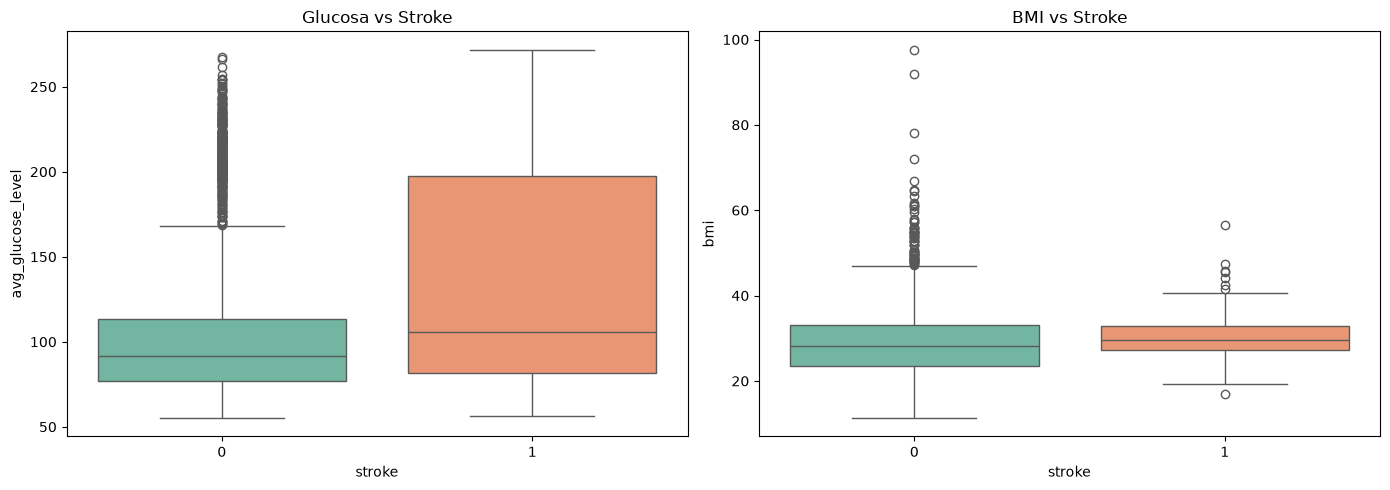

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=X_train.assign(stroke=y_train),
    x="stroke",
    hue="stroke",
    legend=False,
    y="avg_glucose_level",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Glucosa vs Stroke")

sns.boxplot(
    data=X_train.assign(stroke=y_train),
    x="stroke",
    hue="stroke",
    legend=False,
    y="bmi",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("BMI vs Stroke")

plt.tight_layout()
plt.show()

> **Pendiente de desarrollo:** Interpretar las diferencias y el solapamiento de glucosa y BMI entre las clases; delimitar el alcance descriptivo de las asociaciones.


### 4.3. Correlaciones entre variables numéricas y binarias


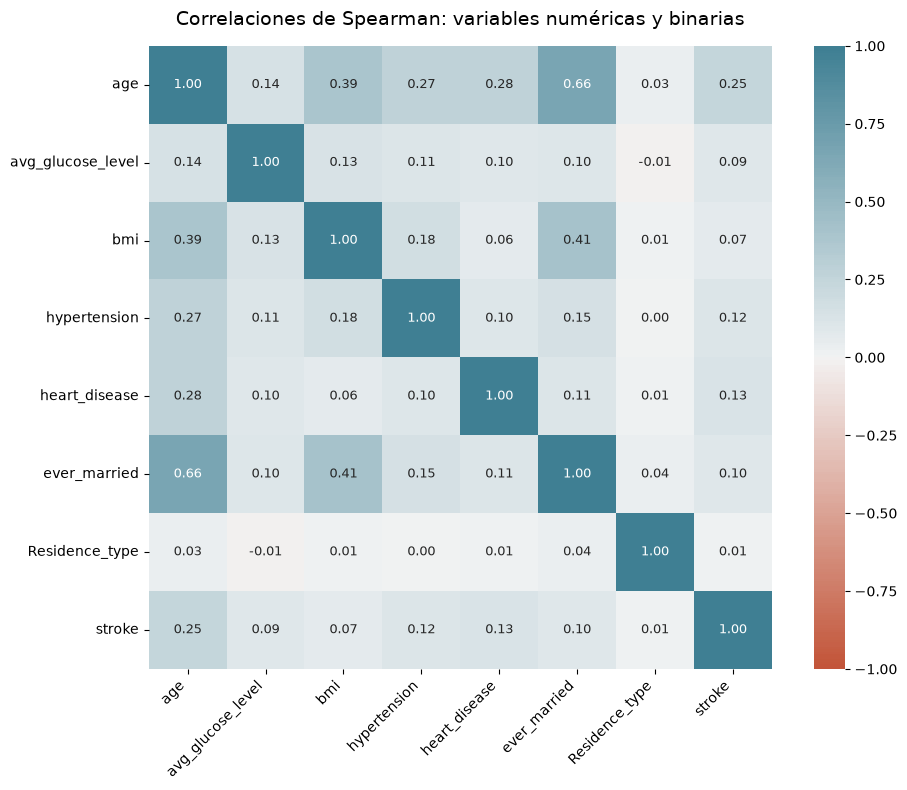

In [115]:
# Se utiliza exclusivamente el conjunto de entrenamiento original.
df_train = pd.concat([X_train, y_train], axis=1)
cols_corr = [
    "age",
    "avg_glucose_level",
    "bmi",
    "hypertension",
    "heart_disease",
    "ever_married",
    "Residence_type",
    "stroke",
]
df_corr = df_train[cols_corr].copy()

# Se asigna explícitamente el significado de las categorías binarias.
df_corr["ever_married"] = df_corr["ever_married"].map({"No": 0, "Yes": 1})
df_corr["Residence_type"] = df_corr["Residence_type"].map({"Rural": 0, "Urban": 1})
if df_corr.isna().any().any():
    raise ValueError("Se detectaron faltantes o categorías binarias no reconocidas.")

corr = df_corr.corr(method="spearman")
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")
plt.title(
    "Correlaciones de Spearman: variables numéricas y binarias", fontsize=14, pad=15
)
plt.tight_layout()
plt.show()


> **Pendiente de desarrollo:** Interpretar las correlaciones principales y explicar su alcance, sin atribuir causalidad ni descartar variables solo por una correlación baja.


### 4.4. Asociación de variables nominales con ACV

A continuación se calcula la cantidad de pacientes, el número de positivos y la proporción de stroke=1 por categoría, exclusivamente en train. Además, se presentan los tamaños de grupo y la prevalencia total como referencias para evitar confundir frecuencia absoluta con proporción de positivos.

pacientes  positivos  stroke_pct
variable       categoria                                        
gender         Female                1823         85        4.66
               Male                  1242         64        5.15
               Other                    1          0        0.00
work_type      Govt_job               388         21        5.41
               Never_worked             7          0        0.00
               Private               1760         89        5.06
               Self-employed          490         38        7.76
               children               421          1        0.24
smoking_status Unknown                932         29        3.11
               formerly smoked        537         44        8.19
               never smoked          1130         49        4.34
               smokes                 467         27        5.78

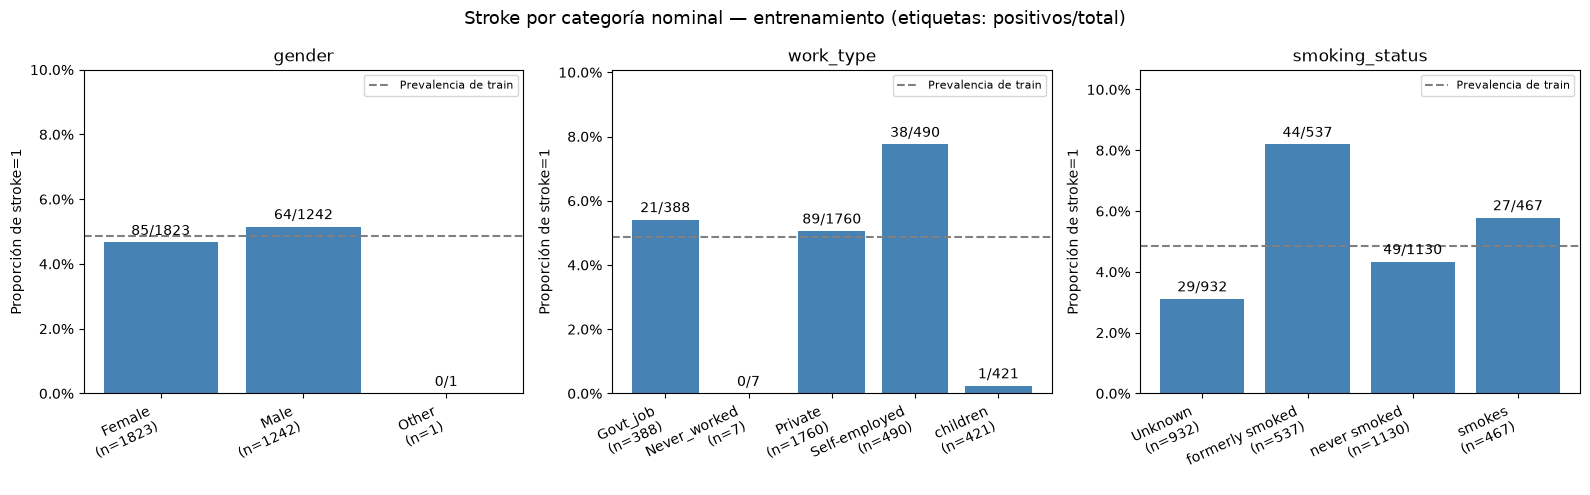

In [116]:
from matplotlib.ticker import PercentFormatter

# Se conservan las categorías nominales sin imponer un orden numérico.
vars_nominales = ["gender", "work_type", "smoking_status"]
resumen_nominales = {}
for col in vars_nominales:
    resumen = df_train.groupby(col, observed=True, dropna=False)["stroke"].agg(
        pacientes="size", positivos="sum", proporcion="mean"
    )
    resumen["positivos"] = resumen["positivos"].astype(int)
    resumen["stroke_pct"] = resumen["proporcion"] * 100
    resumen_nominales[col] = resumen

tabla_nominales = pd.concat(resumen_nominales, names=["variable", "categoria"])
display(tabla_nominales[["pacientes", "positivos", "stroke_pct"]].round(2))

# Se compara la proporción por categoría con la prevalencia global de train.
prevalencia_train = y_train.mean()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, vars_nominales):
    resumen = resumen_nominales[col]
    bars = ax.bar(np.arange(len(resumen)), resumen["proporcion"], color="steelblue")
    ax.set_xticks(np.arange(len(resumen)))
    ax.set_xticklabels(
        [f"{cat}\n(n={int(row['pacientes'])})" for cat, row in resumen.iterrows()],
        rotation=25,
        ha="right",
    )
    ax.bar_label(
        bars,
        labels=[
            f"{int(row['positivos'])}/{int(row['pacientes'])}"
            for _, row in resumen.iterrows()
        ],
        padding=3,
    )
    ax.axhline(
        prevalencia_train, color="gray", linestyle="--", label="Prevalencia de train"
    )
    ax.set_title(col)
    ax.set_ylabel("Proporción de stroke=1")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_ylim(0, max(0.1, resumen["proporcion"].max() * 1.3))
    ax.legend(fontsize=8)
fig.suptitle(
    "Stroke por categoría nominal — entrenamiento (etiquetas: positivos/total)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


> **Pendiente de desarrollo:** Interpretar las proporciones de ACV junto con los tamaños de cada categoría; advertir sobre los grupos con pocos pacientes.


## 5. Codificación y escalado


In [117]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), vars_numericas),
        (
            "categoricas",
            OneHotEncoder(drop="first", sparse_output=False),
            vars_categoricas,
        ),
    ]
)


X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f"Forma de X_train procesado: {X_train_prep.shape}")
print(f"Forma de X_val procesado:   {X_val_prep.shape}")
print(f"Forma de X_test procesado:  {X_test_prep.shape}")

Forma de X_train procesado: (3066, 16)
Forma de X_val procesado:   (1022, 16)
Forma de X_test procesado:  (1022, 16)


> **Pendiente de desarrollo:** Justificar One-Hot Encoding, `drop="first"` y StandardScaler; explicar por qué el preprocesamiento se ajusta con train y se aplica a los otros conjuntos.


## 6. Tratamiento del desbalance y entrenamiento de los MLP

Dado el gran desbalanceo que presenta el dataset en relación a la variable target, se probarán dos métodos distintos para resolverlo. Primero se hará un modelo con BorderlineSMOTE y luegouno con pos_weight, y se compararán resultados.

### 6.1. Sobremuestreo de train con BorderlineSMOTE

La primera prueba utiliza BorderlineSMOTE para sobremuestrear la clase minoritaria **únicamente en train**.


In [ ]:
border_smote = BorderlineSMOTE(random_state=SEED)
X_train_smote, y_train_smote = border_smote.fit_resample(X_train_prep, y_train)

num_features = X_train_smote.shape[1]

print("--- Distribución de 'stroke' antes de BorderlineSMOTE ---")
print(y_train.value_counts())

print("\n--- Distribución de 'stroke' después de BorderlineSMOTE ---")
print(pd.Series(y_train_smote).value_counts())

--- Distribución de 'stroke' antes de BorderlineSMOTE ---
stroke
0    2917
1     149
Name: count, dtype: int64

--- Distribución de 'stroke' después de BorderlineSMOTE ---
stroke
0    2917
1    2917
Name: count, dtype: int64


### 6.2. Entrenamiento del MLP con BorderlineSMOTE

Para comparar las estrategias de balanceo se utiliza la misma arquitectura que con `pos_weight`: una capa oculta de 64 neuronas, ReLU y dropout 0.3. También se mantienen Adam, learning rate 0.001, weight_decay 0.0001, minibatches de 64, semilla 42, un máximo de 500 épocas, paciencia 30 y min_delta de 0.0001.

BorderlineSMOTE entrena con los registros sobremuestreados y pérdida binaria sin ponderar; `pos_weight` entrena con los registros originales y pondera la clase minoritaria que es la positiva. En ambos casos, train original y validación se evalúan al finalizar cada época, con dropout desactivado y sin gradientes. Cada entrenamiento conserva los pesos según su propia pérdida de validación. Las pérdidas ponderada y no ponderada no se comparan directamente.

El recall se registra con umbral 0.5. La comparación final utiliza las mismas métricas y el mismo procedimiento para elegir el umbral F2 en validación. Test no participa en este bloque.

In [10]:
import copy
import random

# Semillas antes de inicializar pesos y barajar los minibatches.
fijar_semilla()


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(out)


# Train sobremuestreado: es el único conjunto que actualiza pesos.
X_train_tensor = torch.tensor(np.asarray(X_train_smote), dtype=torch.float32)
y_train_tensor = torch.tensor(np.asarray(y_train_smote), dtype=torch.float32).view(
    -1, 1
)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Validación: mismos pasos de preprocesamiento, sin sobremuestreo.
X_val_tensor = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).view(-1, 1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Train original para diagnosticar curvas con el desbalance real.
X_train_original_tensor = torch.tensor(np.asarray(X_train_prep), dtype=torch.float32)
y_train_original_tensor = torch.tensor(np.asarray(y_train), dtype=torch.float32).view(
    -1, 1
)
train_original_dataset = TensorDataset(X_train_original_tensor, y_train_original_tensor)
train_eval_loader = DataLoader(train_original_dataset, batch_size=64, shuffle=False)

model = MLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.3)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


def evaluar_modelo(loader):
    # eval() apaga dropout; no_grad() evita calcular gradientes.
    model.eval()
    loss_sum = 0.0
    total = 0
    true_positives = 0
    false_negatives = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits = model(batch_x)
            loss_sum += criterion(logits, batch_y).item() * batch_x.size(0)
            total += batch_x.size(0)
            # Umbral fijo 0.5: equivale a logits >= 0. No se busca un umbral aquí.
            predictions = logits >= 0
            positives = batch_y == 1
            true_positives += (predictions & positives).sum().item()
            false_negatives += ((~predictions) & positives).sum().item()
    if total == 0:
        raise ValueError("No se puede evaluar un conjunto vacío.")
    positive_count = true_positives + false_negatives
    recall = true_positives / positive_count if positive_count else float("nan")
    return loss_sum / total, recall


epochs = 500
patience = 30
min_delta = 1e-4
best_val_loss = float("inf")
best_model_weights = None
best_epoch = None
epochs_without_improvement = 0
history = []

print("Train actualiza pesos; validación selecciona la época; test no participa.")
for epoch in range(1, epochs + 1):
    model.train()  # Reactivar dropout tras las evaluaciones de la época anterior.
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    # Evaluación de train original y val con los mismos pesos y dropout apagado.
    train_loss, train_recall = evaluar_modelo(train_eval_loader)
    val_loss, val_recall = evaluar_modelo(val_loader)
    history.append(
        {
            "epoch": epoch,
            "optimization_loss": running_loss / len(train_dataset),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_recall": train_recall,
            "val_recall": val_recall,
        }
    )
    improved = val_loss < best_val_loss - min_delta
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        # Copia independiente en memoria: no sobrescribe archivos de checkpoints.
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Todas las métricas siguen en history; solo se reduce la salida de consola.
    if epoch % 10 == 0 or epochs_without_improvement == 1:
        status = (
            "Mejora de validación"
            if improved
            else f"Sin mejora suficiente | Paciencia: {epochs_without_improvement}/{patience}"
        )
        print(
            f"Época {epoch:02d}/{epochs} | Loss train: {train_loss:.4f} "
            f"| Loss val: {val_loss:.4f} | Recall train: {train_recall:.3f} "
            f"| Recall val: {val_recall:.3f} | {status}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping: {patience} épocas sin mejora suficiente.")
        break

if best_model_weights is None:
    raise RuntimeError("No se obtuvo un checkpoint válido; revisar datos y pérdidas.")
model.load_state_dict(best_model_weights)
model.eval()
print(f"Mejores pesos restaurados: época {best_epoch}, val loss = {best_val_loss:.4f}")

# Conservar este experimento separado de la alternativa con pos_weight.
model_smote = copy.deepcopy(model)


Train actualiza pesos; validación selecciona la época; test no participa.
Época 06/500 | Loss train: 0.4000 | Loss val: 0.3932 | Recall train: 0.799 | Recall val: 0.680 | Sin mejora suficiente | Paciencia: 1/30
Época 08/500 | Loss train: 0.3924 | Loss val: 0.3871 | Recall train: 0.799 | Recall val: 0.680 | Sin mejora suficiente | Paciencia: 1/30
Época 10/500 | Loss train: 0.3707 | Loss val: 0.3680 | Recall train: 0.799 | Recall val: 0.640 | Mejora de validación
Época 11/500 | Loss train: 0.3728 | Loss val: 0.3704 | Recall train: 0.805 | Recall val: 0.660 | Sin mejora suficiente | Paciencia: 1/30
Época 14/500 | Loss train: 0.3697 | Loss val: 0.3701 | Recall train: 0.805 | Recall val: 0.660 | Sin mejora suficiente | Paciencia: 1/30
Época 17/500 | Loss train: 0.3441 | Loss val: 0.3494 | Recall train: 0.785 | Recall val: 0.620 | Sin mejora suficiente | Paciencia: 1/30
Época 20/500 | Loss train: 0.3412 | Loss val: 0.3505 | Recall train: 0.785 | Recall val: 0.600 | Sin mejora suficiente | Pa

> **Pendiente de desarrollo:** Justificar las decisiones comunes del MLP: ReLU, salida con logits, BCEWithLogitsLoss, Adam, tasa de aprendizaje, dropout, weight decay y selección de pesos mediante validación.


### 6.3. Curvas de entrenamiento con BorderlineSMOTE


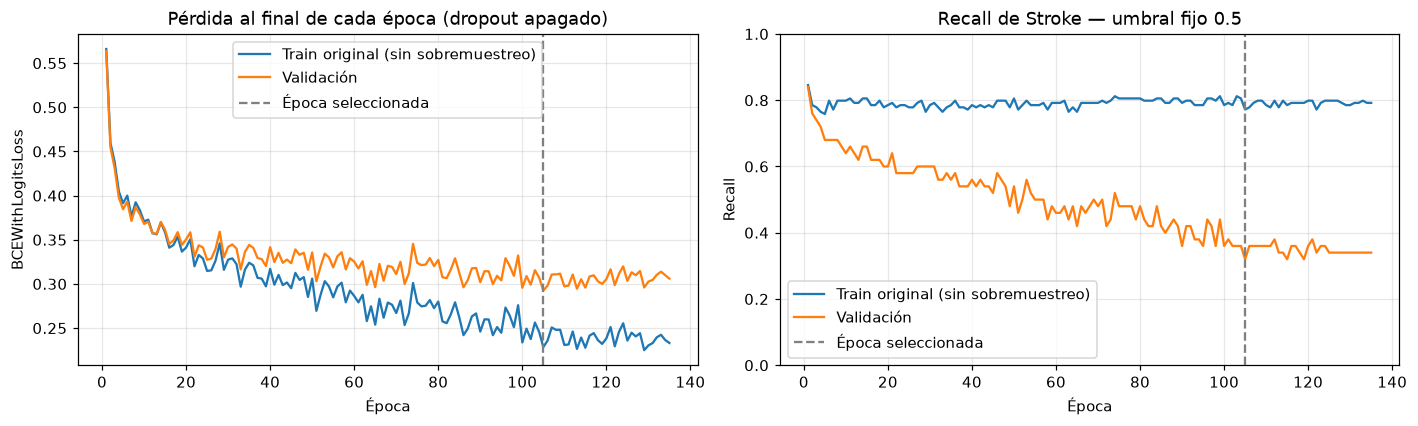

In [11]:
epochs_run = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prefix, label in [
    ("train", "Train original (sin sobremuestreo)"),
    ("val", "Validación"),
]:
    axes[0].plot(epochs_run, [row[f"{prefix}_loss"] for row in history], label=label)
    axes[1].plot(epochs_run, [row[f"{prefix}_recall"] for row in history], label=label)

axes[0].set_title("Pérdida al final de cada época (dropout apagado)")
axes[0].set_ylabel("BCEWithLogitsLoss")
axes[1].set_title("Recall de Stroke — umbral fijo 0.5")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.axvline(best_epoch, color="gray", linestyle="--", label="Época seleccionada")
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


> **Pendiente de desarrollo:** Interpretar la evolución de pérdida y recall, la época seleccionada y la detención temprana en BorderlineSMOTE; aclarar el umbral fijo de las curvas.


### 6.4. Entrenamiento del MLP con `pos_weight`

Como segundo método se decidió probar con pos_weight, dándole más peso a la clase minoritaria.

Se utiliza inicialmente una capa oculta de 64 neuronas con ReLU y dropout 0.3. Esta configuración se toma como punto de partida y se contrasta con alternativas en el bloque siguiente. La salida produce un logit, compatible con la pérdida `BCEWithLogitsLoss`.


In [12]:
import copy
import random

fijar_semilla()

X_tr_np = (
    X_train_prep.values if hasattr(X_train_prep, "values") else np.array(X_train_prep)
)
y_tr_np = y_train.values if hasattr(y_train, "values") else np.array(y_train)


X_train_t = torch.tensor(X_tr_np, dtype=torch.float32)
y_train_t = torch.tensor(y_tr_np, dtype=torch.float32).view(-1, 1)


batch_size = 64
dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


class CleanMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout_rate=0.3):
        super(CleanMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


num_negatives = (y_tr_np == 0).sum()
num_positives = (y_tr_np == 1).sum()
if num_positives == 0 or num_negatives == 0:
    raise ValueError("Se requieren ambas clases en train.")
weight_val = num_negatives / num_positives

pos_weight = torch.tensor([weight_val], dtype=torch.float32)
print(f"Peso asignado a la clase 'Stroke': {weight_val:.2f}")

num_features = X_tr_np.shape[1]
model_pos_weight = CleanMLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.3)

criterion_pos_weight = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_pos_weight = optim.Adam(
    model_pos_weight.parameters(), lr=0.001, weight_decay=1e-4
)


# Train original: no se generan ni se usan ejemplos sintéticos.
train_dataset = dataset
train_eval_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
X_val_tensor = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).view(-1, 1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


def evaluar_pos_weight(loader):
    # eval() apaga dropout; no_grad() evita calcular gradientes.
    model_pos_weight.eval()
    loss_sum = 0.0
    total = 0
    true_positives = 0
    false_negatives = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits = model_pos_weight(batch_x)
            loss_sum += criterion_pos_weight(logits, batch_y).item() * batch_x.size(0)
            total += batch_x.size(0)
            # Umbral fijo 0.5: equivale a logits >= 0. No se busca un umbral aquí.
            predictions = logits >= 0
            positives = batch_y == 1
            true_positives += (predictions & positives).sum().item()
            false_negatives += ((~predictions) & positives).sum().item()
    if total == 0:
        raise ValueError("No se puede evaluar un conjunto vacío.")
    positive_count = true_positives + false_negatives
    recall = true_positives / positive_count if positive_count else float("nan")
    return loss_sum / total, recall


epochs_pos_weight = 500
patience_pos_weight = 30
min_delta_pos_weight = 1e-4
best_val_loss_pos_weight = float("inf")
best_weights_pos_weight = None
best_epoch_pos_weight = None
bad_epochs_pos_weight = 0
history_pos_weight = []

print(
    "Train original ajusta pesos con pos_weight; validación selecciona la época; test no participa."
)
for epoch in range(1, epochs_pos_weight + 1):
    model_pos_weight.train()  # Reactivar dropout tras las evaluaciones de la época anterior.
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer_pos_weight.zero_grad()
        logits = model_pos_weight(batch_x)
        loss = criterion_pos_weight(logits, batch_y)
        loss.backward()
        optimizer_pos_weight.step()
        running_loss += loss.item() * batch_x.size(0)

    # Evaluación de train original y val con los mismos pesos y dropout apagado.
    train_loss, train_recall = evaluar_pos_weight(train_eval_loader)
    val_loss, val_recall = evaluar_pos_weight(val_loader)
    history_pos_weight.append(
        {
            "epoch": epoch,
            "optimization_loss": running_loss / len(train_dataset),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_recall": train_recall,
            "val_recall": val_recall,
        }
    )
    improved = val_loss < best_val_loss_pos_weight - min_delta_pos_weight
    if improved:
        best_val_loss_pos_weight = val_loss
        best_epoch_pos_weight = epoch
        # Copia independiente en memoria: no sobrescribe archivos de checkpoints.
        best_weights_pos_weight = copy.deepcopy(model_pos_weight.state_dict())
        bad_epochs_pos_weight = 0
    else:
        bad_epochs_pos_weight += 1

    # Todas las métricas siguen en history_pos_weight; solo se reduce la salida de consola.
    if epoch % 10 == 0 or bad_epochs_pos_weight == 1:
        status = (
            "Mejora de validación"
            if improved
            else f"Sin mejora suficiente | Paciencia: {bad_epochs_pos_weight}/{patience_pos_weight}"
        )
        print(
            f"Época {epoch:02d}/{epochs_pos_weight} | Loss train: {train_loss:.4f} "
            f"| Loss val: {val_loss:.4f} | Recall train: {train_recall:.3f} "
            f"| Recall val: {val_recall:.3f} | {status}"
        )

    if bad_epochs_pos_weight >= patience_pos_weight:
        print(f"Early stopping: {patience_pos_weight} épocas sin mejora suficiente.")
        break

if best_weights_pos_weight is None:
    raise RuntimeError("No se obtuvo un checkpoint válido; revisar datos y pérdidas.")
model_pos_weight.load_state_dict(best_weights_pos_weight)
model_pos_weight.eval()
print(
    f"Mejores pesos restaurados: época {best_epoch_pos_weight}, val loss = {best_val_loss_pos_weight:.4f}"
)


Peso asignado a la clase 'Stroke': 19.58
Train original ajusta pesos con pos_weight; validación selecciona la época; test no participa.
Época 10/500 | Loss train: 0.8788 | Loss val: 0.9009 | Recall train: 0.852 | Recall val: 0.880 | Mejora de validación
Época 12/500 | Loss train: 0.8717 | Loss val: 0.9017 | Recall train: 0.846 | Recall val: 0.840 | Sin mejora suficiente | Paciencia: 1/30
Época 14/500 | Loss train: 0.8673 | Loss val: 0.8997 | Recall train: 0.852 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 1/30
Época 17/500 | Loss train: 0.8614 | Loss val: 0.8981 | Recall train: 0.859 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 1/30
Época 20/500 | Loss train: 0.8558 | Loss val: 0.8959 | Recall train: 0.859 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 4/30
Época 30/500 | Loss train: 0.8392 | Loss val: 0.9094 | Recall train: 0.859 | Recall val: 0.820 | Sin mejora suficiente | Paciencia: 14/30
Época 40/500 | Loss train: 0.8235 | Loss val: 0.9130 | Recal

> **Pendiente de desarrollo:** Explicar el cálculo de `pos_weight` con train y su efecto sobre la pérdida y los errores de la clase positiva.


### 6.5. Curvas de entrenamiento con `pos_weight`


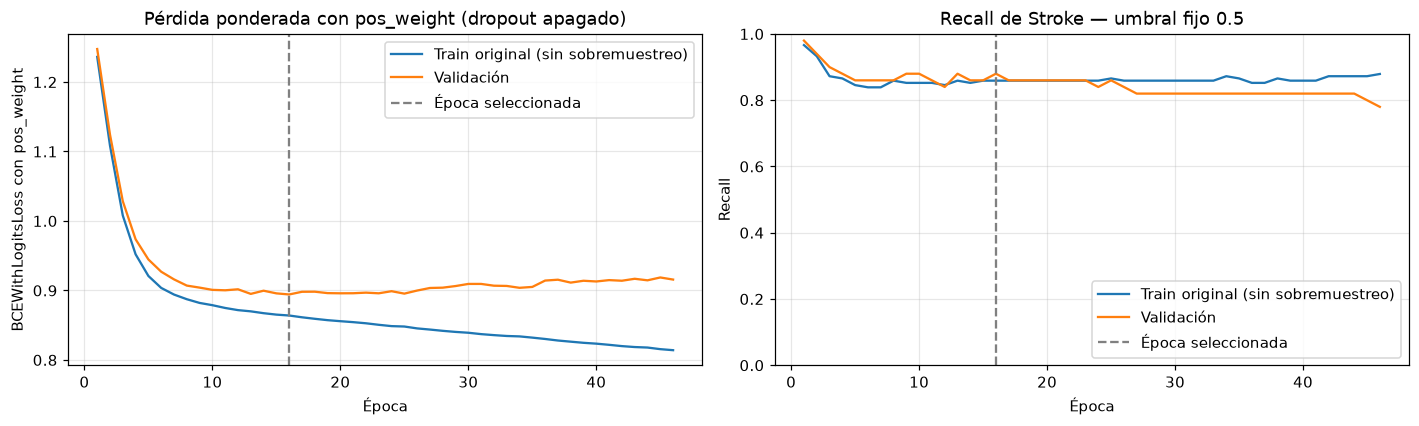

In [13]:
epochs_run = [row["epoch"] for row in history_pos_weight]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prefix, label in [
    ("train", "Train original (sin sobremuestreo)"),
    ("val", "Validación"),
]:
    axes[0].plot(
        epochs_run, [row[f"{prefix}_loss"] for row in history_pos_weight], label=label
    )
    axes[1].plot(
        epochs_run, [row[f"{prefix}_recall"] for row in history_pos_weight], label=label
    )

axes[0].set_title("Pérdida ponderada con pos_weight (dropout apagado)")
axes[0].set_ylabel("BCEWithLogitsLoss con pos_weight")
axes[1].set_title("Recall de Stroke — umbral fijo 0.5")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.axvline(
        best_epoch_pos_weight, color="gray", linestyle="--", label="Época seleccionada"
    )
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


> **Pendiente de desarrollo:** Interpretar las curvas y la época seleccionada con `pos_weight`; analizar posibles señales de sobreajuste y aclarar por qué las pérdidas de ambos métodos no se comparan directamente.


## 7. Comparación de arquitecturas MLP

Se toma el MLP original de una capa oculta de 64 neuronas como referencia y se compara con dos alternativas: una capa de 32 neuronas y dos capas de 64 y 32 neuronas. La primera permite examinar si reducir la capacidad conserva el desempeño; la segunda permite evaluar el efecto de agregar profundidad. En los tres casos se construye un MLP para clasificación binaria.

Se mantienen la partición, el preprocesamiento, `pos_weight`, Adam (lr=0.001, weight_decay=0.0001), batch size 64 y ReLU con dropout 0.3 después de cada capa oculta. Se utiliza la misma semilla `SEED = 42` para las tres arquitecturas, hasta 500 épocas y paciencia 30. Se seleccionan los pesos por pérdida de validación y el umbral por F2. Al agregar una capa también se incorpora un bloque adicional de ReLU y dropout; se comparan las configuraciones completas bajo esa regla común.

La comparación utiliza únicamente train y validación. Test queda fuera de la selección de arquitectura y umbral.


### 7.1. Funciones de evaluación y selección de umbral

Se definen funciones comunes para comparar métricas y elegir umbrales exclusivamente en validación. Se reutilizan posteriormente en la comparación de los métodos de tratamiento del desbalance.


In [123]:
from sklearn.metrics import fbeta_score, average_precision_score


def probabilidades_validacion(modelo, features):
    parameter = next(modelo.parameters())
    features_tensor = torch.tensor(
        np.asarray(features), dtype=torch.float32, device=parameter.device
    )
    modelo.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(modelo(features_tensor)).cpu().numpy().reshape(-1)
    if not np.isfinite(probabilities).all():
        raise ValueError("Se obtuvieron probabilidades no finitas.")
    return probabilities


def metricas_binarias(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "Umbral": float(threshold),
        "Accuracy": accuracy_score(labels, predictions),
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Recall": recall_score(labels, predictions, zero_division=0),
        "F1": f1_score(labels, predictions, zero_division=0),
        "F2": fbeta_score(labels, predictions, beta=2, zero_division=0),
        "AUC_ROC": roc_auc_score(labels, probabilities),
        "AP": average_precision_score(labels, probabilities),
        "Especificidad": tn / (tn + fp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Alertas": int(tp + fp),
    }


def elegir_umbral_f2(labels, probabilities):
    # Una fila por umbral observado: cubre todos los cambios de clasificación.
    precision, recall, thresholds = precision_recall_curve(labels, probabilities)
    # El último punto de la curva no tiene un umbral asociado.
    precision, recall = precision[:-1], recall[:-1]
    denominator = 4 * precision + recall
    scores = np.divide(
        5 * precision * recall,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    )
    candidates = pd.DataFrame(
        {
            "Umbral": thresholds,
            "Precision": precision,
            "Recall": recall,
            "F2": scores,
        }
    )
    denominator_f1 = precision + recall
    candidates["F1"] = np.divide(
        2 * precision * recall,
        denominator_f1,
        out=np.zeros_like(denominator_f1),
        where=denominator_f1 > 0,
    )
    # Empates numéricos en F2: preferir mayor precisión y luego mayor umbral.
    tied = candidates[
        np.isclose(candidates["F2"], candidates["F2"].max(), rtol=0, atol=1e-12)
    ]
    best = tied.sort_values(["Precision", "Umbral"], ascending=[False, False]).iloc[0]
    return float(best["Umbral"]), candidates


def elegir_umbral_f1(labels, probabilities):
    # Se conservan los mismos candidatos y la misma regla de desempate.
    _, candidates = elegir_umbral_f2(labels, probabilities)
    tied = candidates[
        np.isclose(candidates["F1"], candidates["F1"].max(), rtol=0, atol=1e-12)
    ]
    best = tied.sort_values(["Precision", "Umbral"], ascending=[False, False]).iloc[0]
    return float(best["Umbral"]), candidates




### 7.2. Entrenamiento y comparación de tres arquitecturas

Se entrena una vez cada MLP con la misma semilla definida al inicio. Se presentan métricas individuales de validación, sin promedios ni desvíos entre semillas. Los modelos de los experimentos se mantienen separados de `model_smote` y `model_pos_weight`.


In [124]:
import time


def comparar_arquitecturas():
    # Las variables y los modelos experimentales quedan dentro de esta función.

    MAX_EPOCHS, PATIENCE, MIN_DELTA = 500, 30, 1e-4
    BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY, DROPOUT = 64, 0.001, 1e-4, 0.3
    input_dim = X_train_prep.shape[1]
    Xtr = torch.tensor(np.asarray(X_train_prep), dtype=torch.float32)
    ytr = torch.tensor(np.asarray(y_train), dtype=torch.float32).reshape(-1, 1)
    Xva = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
    yva = torch.tensor(np.asarray(y_val), dtype=torch.float32).reshape(-1, 1)
    labels_val = np.asarray(y_val)
    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32)
    class Arquitectura(nn.Module):
        def __init__(self, input_dim, hidden_sizes):
            super().__init__()
            layers, previous = [], input_dim
            for width in hidden_sizes:
                layers.extend([nn.Linear(previous, width), nn.ReLU(), nn.Dropout(DROPOUT)])
                previous = width
            layers.append(nn.Linear(previous, 1))
            self.network = nn.Sequential(*layers)
        def forward(self, x):
            return self.network(x)


    def evaluar(model, loader, criterion):
        model.eval()
        loss_sum, total, tp, positives = 0.0, 0, 0, 0
        with torch.no_grad():
            for features, labels in loader:
                logits = model(features)
                loss_sum += criterion(logits, labels).item() * len(features)
                total += len(features)
                positive_mask = labels == 1
                positives += positive_mask.sum().item()
                tp += ((logits >= 0) & positive_mask).sum().item()
        return loss_sum / total, tp / positives


    def entrenar(name, hidden_sizes, seed):
        fijar_semilla(seed)
        train_dataset = TensorDataset(Xtr, ytr)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        model = Arquitectura(input_dim, hidden_sizes)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        train_eval = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
        val_eval = DataLoader(TensorDataset(Xva, yva), batch_size=BATCH_SIZE, shuffle=False)
        best_loss, best_epoch, best_weights, bad_epochs = float("inf"), None, None, 0
        history = []
        started = time.perf_counter()
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for features, labels in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(features), labels)
                loss.backward(); optimizer.step()
            train_loss, train_recall = evaluar(model, train_eval, criterion)
            val_loss, val_recall = evaluar(model, val_eval, criterion)
            if not np.isfinite(train_loss) or not np.isfinite(val_loss):
                raise RuntimeError(f"Pérdida no finita: {name}, semilla {seed}.")
            history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                            "train_recall": train_recall, "val_recall": val_recall})
            if val_loss < best_loss - MIN_DELTA:
                best_loss, best_epoch = val_loss, epoch
                best_weights = copy.deepcopy(model.state_dict()); bad_epochs = 0
            else:
                bad_epochs += 1
            if bad_epochs >= PATIENCE:break
        model.load_state_dict(best_weights); model.eval()
        restored_loss, _ = evaluar(model, val_eval, criterion)
        assert abs(restored_loss - best_loss) < 1e-8
        with torch.no_grad():scores = torch.sigmoid(model(Xva)).numpy().reshape(-1)
        threshold_f2, _ = elegir_umbral_f2(labels_val, scores)
        threshold_f1, _ = elegir_umbral_f1(labels_val, scores)
        row = {"Arquitectura": name, "Semilla": seed,
               "Capas": " → ".join(map(str, [input_dim, *hidden_sizes, 1])),
               "Parametros": sum(p.numel() for p in model.parameters()),
               "Mejor_epoca": best_epoch, "Epocas": len(history), "Val_loss": best_loss,
               "Segundos": time.perf_counter() - started,
               **metricas_binarias(labels_val, scores, threshold_f2)}
        baseline = metricas_binarias(labels_val, scores, 0.5)
        row.update({"F2_umbral_05": baseline["F2"], "Recall_umbral_05": baseline["Recall"],
                    "Umbral_F1": threshold_f1,
                    "F1_optimizado": metricas_binarias(labels_val, scores, threshold_f1)["F1"]})
        return row, history

    rows, histories = [], {}
    for name, hidden_sizes in {"MLP 64": (64,), "MLP 32": (32,), "MLP 64-32": (64, 32)}.items():
        for seed in [SEED]:
            row, history = entrenar(name, hidden_sizes, seed)
            rows.append(row)
            histories[(name, seed)] = pd.DataFrame(history)
            print(f"{name} | semilla {seed}: F2={row['F2']:.4f}, "
                  f"precisión={row['Precision']:.3f}, recall={row['Recall']:.3f}, "
                  f"mejor época={row['Mejor_epoca']}", flush=True)
    return pd.DataFrame(rows), histories


# Se preservan los generadores y la configuración del entorno principal.
estado_random = random.getstate()
estado_numpy = np.random.get_state()
hilos_previos = torch.get_num_threads()
try:
    torch.set_num_threads(1)
    with torch.random.fork_rng(devices=[]):
        resultados_arquitecturas, historiales_arquitecturas = comparar_arquitecturas()
finally:
    random.setstate(estado_random)
    np.random.set_state(estado_numpy)
    torch.set_num_threads(hilos_previos)

resumen_arquitecturas = resultados_arquitecturas.set_index("Arquitectura")[
    ["Semilla", "Parametros", "F2", "Precision", "Recall", "FP", "FN", "Mejor_epoca"]
]
display(resumen_arquitecturas.round(4))


MLP 64 | semilla 42: F2=0.4366, precisión=0.149, recall=0.840, mejor época=16
MLP 32 | semilla 42: F2=0.4343, precisión=0.151, recall=0.820, mejor época=24
MLP 64-32 | semilla 42: F2=0.4310, precisión=0.152, recall=0.800, mejor época=9


,Semilla,Parametros,F2,Precision,Recall,FP,FN,Mejor_epoca
Arquitectura,,,,,,,,
MLP 64,42,1153,0.4366,0.1495,0.84,239,8,16
MLP 32,42,577,0.4343,0.1507,0.82,231,9,24
MLP 64-32,42,3201,0.4310,0.1515,0.80,224,10,9


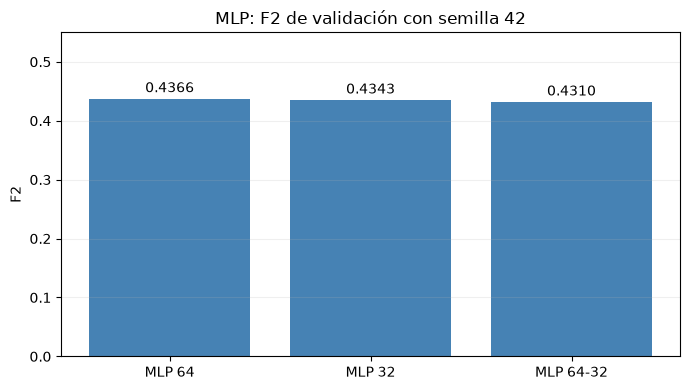

In [125]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(resumen_arquitecturas.index, resumen_arquitecturas["F2"], color="steelblue")
for posicion, valor in enumerate(resumen_arquitecturas["F2"]):
    ax.annotate(f"{valor:.4f}", xy=(posicion, valor), xytext=(0, 5),
                textcoords="offset points", ha="center")
ax.set_ylim(0, 0.55)
ax.set_title(f"MLP: F2 de validación con semilla {SEED}")
ax.set_ylabel("F2")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### 7.3. Resultados y selección de arquitectura

Las tres arquitecturas presentan resultados cercanos. El MLP de 64 neuronas alcanza el mayor F2 de validación (0.4366), seguido por el de 32 (0.4343) y el de dos capas de 64–32 (0.4310). El modelo de 32 reduce aproximadamente a la mitad la cantidad de parámetros, mientras que agregar una segunda capa aumenta la complejidad sin mejorar F2 en esta prueba.

Se mantiene el MLP de 64 neuronas porque detecta 42 de los 50 positivos de validación, frente a 41 del modelo de 32. Dado el context de aplicación del modelo y el objetivo de reducir los falsos negativos, esa detección adicional tiene mayor prioridad que la reducción de parámetros. Se toleran los 8 falsos positivos más: 239 vs 231.


## 8. Comparación de estrategias y selección en validación

### 8.1. Obtención de scores de validación


In [14]:
# Compatibilidad con un kernel donde el primer entrenamiento se ejecutó antes
# de agregar el nombre model_smote. El primer MLP sigue almacenado como model.
if "model_smote" not in globals():
    if "model" not in globals() or model.__class__.__name__ != "MLP":
        raise RuntimeError("Ejecutá primero el entrenamiento con SMOTE.")
    model_smote = copy.deepcopy(model)
if "model_pos_weight" not in globals():
    raise RuntimeError("Ejecutá primero el entrenamiento con pos_weight.")

labels_val = np.asarray(y_val).reshape(-1)
if set(np.unique(labels_val)) != {0, 1}:
    raise ValueError("Validación debe contener ambas clases.")
models_val = {
    "BorderlineSMOTE": model_smote,
    "pos_weight": model_pos_weight,
}
probabilities_val = {
    name: probabilidades_validacion(modelo, X_val_prep)
    for name, modelo in models_val.items()
}
if any(
    len(probabilities) != len(labels_val)
    for probabilities in probabilities_val.values()
):
    raise ValueError("Las predicciones deben estar alineadas con y_val.")

print(
    f"Validación: {len(labels_val)} pacientes; {int(labels_val.sum())} positivos "
    f"({labels_val.mean():.2%}). Ambos modelos usan las mismas filas."
)


Validación: 1022 pacientes; 50 positivos (4.89%). Ambos modelos usan las mismas filas.


### 8.2. Comparación con umbral fijo de 0,5


In [15]:
fixed_rows = [
    {
        "Modelo": name,
        "Regla": "Umbral 0.5",
        **metricas_binarias(labels_val, probabilities, 0.5),
    }
    for name, probabilities in probabilities_val.items()
]
fixed_rows.append(
    {
        "Modelo": "Referencia: siempre negativo",
        "Regla": "Umbral 0.5",
        **metricas_binarias(labels_val, np.zeros(len(labels_val)), 0.5),
    }
)
comparison_fixed = pd.DataFrame(fixed_rows)
display(comparison_fixed.round(4))


,Modelo,Regla,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,BorderlineSMOTE,Umbral 0.5,0.5,0.8620,0.1301,0.32,0.1850,0.2477,0.8012,0.1401,0.8899,865,107,34,16,123
1,pos_weight,Umbral 0.5,0.5,0.7231,0.1371,0.88,0.2372,0.4223,0.8380,0.1631,0.7150,695,277,6,44,321
2,Referencia: siempre negativo,Umbral 0.5,0.5,0.9511,0.0000,0.00,0.0000,0.0000,0.5000,0.0489,1.0000,972,0,50,0,0


> **Pendiente de desarrollo:** Interpretar la comparación con umbral 0,5 y la referencia siempre negativa; explicar por qué accuracy resulta insuficiente ante el desbalance.


### 8.3. Selección de umbrales mediante F1 y F2


In [16]:
thresholds_f2 = {}
thresholds_f1 = {}
optimized_rows_f1 = []
threshold_curves = {}
optimized_rows = []
for name, probabilities in probabilities_val.items():
    threshold, candidates = elegir_umbral_f2(labels_val, probabilities)
    threshold_f1, _ = elegir_umbral_f1(labels_val, probabilities)
    thresholds_f1[name] = threshold_f1
    optimized_rows_f1.append(
        {
            "Modelo": name,
            "Regla": "Umbral elegido por F1 en val",
            **metricas_binarias(labels_val, probabilities, threshold_f1),
        }
    )
    thresholds_f2[name] = threshold
    threshold_curves[name] = candidates
    optimized_rows.append(
        {
            "Modelo": name,
            "Regla": "Umbral elegido por F2 en val",
            **metricas_binarias(labels_val, probabilities, threshold),
        }
    )
comparison_f2 = pd.DataFrame(optimized_rows)
comparison_f1 = pd.DataFrame(optimized_rows_f1)
comparison_thresholds = pd.concat([comparison_f1, comparison_f2], ignore_index=True)
display(comparison_thresholds.round(4))

# Selección reproducible por F2; en empate se prefiere precisión y luego recall.
ranked = comparison_f2.sort_values(
    ["F2", "Precision", "Recall", "Modelo"], ascending=[False, False, False, True]
)
selected_name = ranked.iloc[0]["Modelo"]
selected_model = models_val[selected_name]
selected_threshold = thresholds_f2[selected_name]
print(f"Configuración seleccionada en validación: {selected_name}")
print(f"Umbral que se conservaría para test: {selected_threshold:.6f}")


Configuración seleccionada en validación: pos_weight
Umbral que se conservaría para test: 0.567368


,Modelo,Regla,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,BorderlineSMOTE,Umbral elegido por F1 en val,0.3097,0.8190,0.1466,0.56,0.2324,0.3581,0.8012,0.1401,0.8323,809,163,22,28,191
1,pos_weight,Umbral elegido por F1 en val,0.7138,0.8415,0.1706,0.58,0.2636,0.3919,0.8380,0.1631,0.8549,831,141,21,29,170
2,BorderlineSMOTE,Umbral elegido por F2 en val,0.0587,0.7153,0.1223,0.78,0.2114,0.3757,0.8012,0.1401,0.7119,692,280,11,39,319
3,pos_weight,Umbral elegido por F2 en val,0.5674,0.7583,0.1495,0.84,0.2538,0.4366,0.8380,0.1631,0.7541,733,239,8,42,281


> **Pendiente de desarrollo:** Justificar F2 como criterio de selección y contrastarlo con F1; interpretar los umbrales y el compromiso entre recall, precisión y falsas alertas.


### 8.4. Matrices de confusión en validación


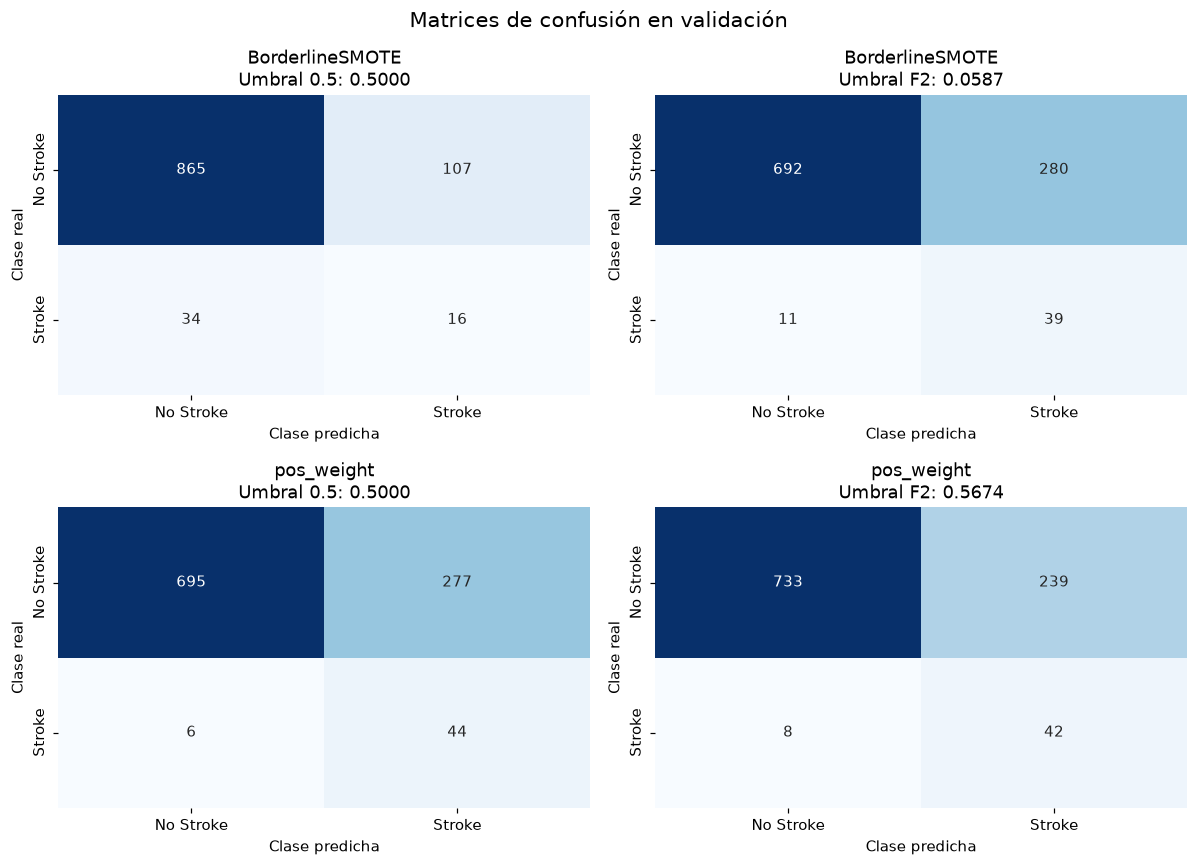

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (name, probabilities) in enumerate(probabilities_val.items()):
    for col, (rule, threshold) in enumerate(
        [
            ("Umbral 0.5", 0.5),
            ("Umbral F2", thresholds_f2[name]),
        ]
    ):
        predictions = (probabilities >= threshold).astype(int)
        matrix = confusion_matrix(labels_val, predictions, labels=[0, 1])
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"],
            ax=axes[row, col],
        )
        axes[row, col].set_title(f"{name}\n{rule}: {threshold:.4f}")
        axes[row, col].set_xlabel("Clase predicha")
        axes[row, col].set_ylabel("Clase real")
fig.suptitle("Matrices de confusión en validación", fontsize=14)
plt.tight_layout()
plt.show()


> **Pendiente de desarrollo:** Interpretar los cambios en TP, FN, FP y TN al ajustar el umbral; explicar la prioridad de reducir falsos negativos y el costo de las falsas alertas.


### 8.5. Curvas ROC, precisión-recall y métricas según el umbral


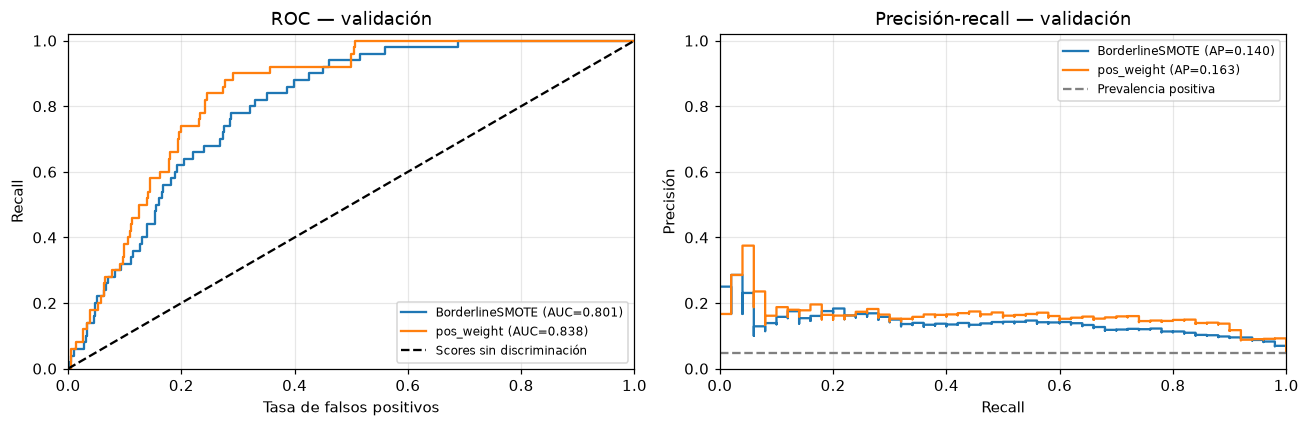

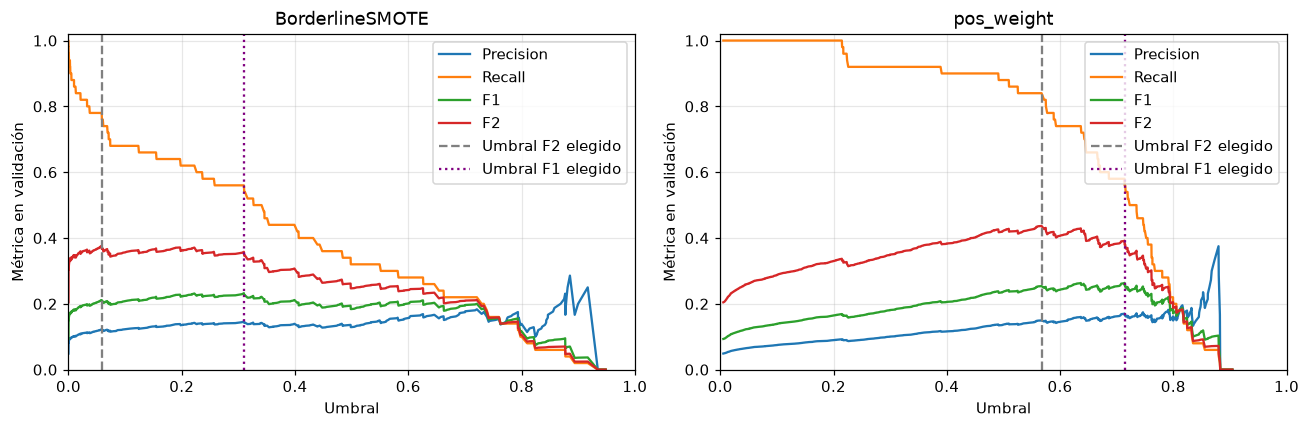

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, probabilities in probabilities_val.items():
    fpr, tpr, _ = roc_curve(labels_val, probabilities)
    precision, recall, _ = precision_recall_curve(labels_val, probabilities)
    axes[0].plot(
        fpr, tpr, label=f"{name} (AUC={roc_auc_score(labels_val, probabilities):.3f})"
    )
    axes[1].step(
        recall,
        precision,
        where="post",
        label=f"{name} (AP={average_precision_score(labels_val, probabilities):.3f})",
    )
axes[0].plot([0, 1], [0, 1], "k--", label="Scores sin discriminación")
axes[0].set(
    title="ROC — validación", xlabel="Tasa de falsos positivos", ylabel="Recall"
)
axes[1].axhline(
    labels_val.mean(), color="gray", linestyle="--", label="Prevalencia positiva"
)
axes[1].set(title="Precisión-recall — validación", xlabel="Recall", ylabel="Precisión")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, candidates) in zip(axes, threshold_curves.items()):
    for metric in ["Precision", "Recall", "F1", "F2"]:
        ax.plot(candidates["Umbral"], candidates[metric], label=metric)
    ax.axvline(
        thresholds_f2[name], color="gray", linestyle="--", label="Umbral F2 elegido"
    )
    ax.axvline(
        thresholds_f1[name], color="purple", linestyle=":", label="Umbral F1 elegido"
    )
    ax.set(
        title=name,
        xlabel="Umbral",
        ylabel="Métrica en validación",
        xlim=(0, 1),
        ylim=(0, 1.02),
    )
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


> **Pendiente de desarrollo:** Interpretar AUC-ROC y precisión promedio junto con las curvas; explicar el papel de la prevalencia como referencia en precisión-recall.


### 8.6. Comparación final y selección de configuración

Se comparan BorderlineSMOTE y `pos_weight` utilizando la misma arquitectura e hiperparámetros de entrenamiento. La diferencia entre las estrategias es el uso de registros sintéticos con pérdida sin ponderar frente al uso de registros originales con pérdida ponderada. Cada entrenamiento conserva los pesos según su propia pérdida de validación; la comparación utiliza las mismas métricas y el mismo procedimiento de selección de umbral.

Con el umbral F2 de cada modelo, `pos_weight` alcanza F2 de 0.4366 y recall de 0.84, frente a 0.3757 y 0.78 de BorderlineSMOTE. También presenta menos falsos positivos (239 frente a 280) y falsos negativos (8 frente a 11), por lo que se conserva para la evaluación final.

BorderlineSMOTE mantiene carácter exploratorio por la interpolación de categorías codificadas. Sus resultados permiten comparar el comportamiento de esta implementación, pero no establecer superioridad general de un método de balanceo.


In [19]:
winner = ranked.iloc[0]
print(f"Selección provisional por F2 en val: {selected_name}.")
for _, row in comparison_f2.iterrows():
    original = comparison_fixed[comparison_fixed["Modelo"] == row["Modelo"]].iloc[0]
    print(
        f"\n{row['Modelo']}: umbral={row['Umbral']:.4f}; F2 {original['F2']:.3f} -> {row['F2']:.3f}."
    )
    print(
        f"Precisión={row['Precision']:.3f}, recall={row['Recall']:.3f}, F1={row['F1']:.3f}; "
        f"TP={int(row['TP'])}, FN={int(row['FN'])}, FP={int(row['FP'])}, TN={int(row['TN'])}."
    )
    print(
        f"Genera {int(row['Alertas'])} alertas; {int(row['FP'])} son falsas. "
        f"Frente a 0.5: cambio FN={int(row['FN'] - original['FN']):+d}, "
        f"cambio FP={int(row['FP'] - original['FP']):+d}."
    )
print(
    "\nLa selección se hizo usando validación. La evaluación en test se presenta en el bloque siguiente, conservando esta selección."
)
print(
    "El F2 elegido no impone un mínimo de precisión; revisar si las falsas alertas son aceptables."
)


Selección provisional por F2 en val: pos_weight.

BorderlineSMOTE: umbral=0.0587; F2 0.248 -> 0.376.
Precisión=0.122, recall=0.780, F1=0.211; TP=39, FN=11, FP=280, TN=692.
Genera 319 alertas; 280 son falsas. Frente a 0.5: cambio FN=-23, cambio FP=+173.

pos_weight: umbral=0.5674; F2 0.422 -> 0.437.
Precisión=0.149, recall=0.840, F1=0.254; TP=42, FN=8, FP=239, TN=733.
Genera 281 alertas; 239 son falsas. Frente a 0.5: cambio FN=+2, cambio FP=-38.

La selección se hizo usando validación. La evaluación en test se presenta en el bloque siguiente, conservando esta selección.
El F2 elegido no impone un mínimo de precisión; revisar si las falsas alertas son aceptables.


## 9. Evaluación final en test

### 9.1. Métricas de la configuración seleccionada

Se evalúa la configuración y el umbral F2 seleccionados exclusivamente en validación, utilizando los mejores pesos restaurados. No se ajustan parámetros, pesos ni umbrales con test. Se informa accuracy, precisión, recall, F1, F2, AUC-ROC y precisión promedio (AP).


In [132]:
# Se conservan la configuración y el umbral seleccionados en validación.
if not all(nombre in globals() for nombre in [
    "selected_name", "selected_model", "selected_threshold", "metricas_binarias"
]):
    raise RuntimeError("Se debe ejecutar primero la selección en validación.")

nombre_test = selected_name
umbral_test = float(selected_threshold)
modelo_test = selected_model
if not np.isfinite(umbral_test) or not 0 <= umbral_test <= 1:
    raise ValueError("El umbral seleccionado debe ser finito y estar entre 0 y 1.")

labels_test = np.asarray(y_test).reshape(-1)
if set(np.unique(labels_test)) != {0, 1}:
    raise ValueError("Test debe contener ambas clases para calcular AUC-ROC.")

parameter = next(modelo_test.parameters())
features_test = torch.tensor(
    np.asarray(X_test_prep), dtype=torch.float32, device=parameter.device
)
modelo_test.eval()
with torch.no_grad():
    probabilities_test = torch.sigmoid(modelo_test(features_test)).cpu().numpy().reshape(-1)

if len(probabilities_test) != len(labels_test) or not np.isfinite(probabilities_test).all():
    raise ValueError("Se requieren scores finitos y alineados con y_test.")

predictions_test = (probabilities_test >= umbral_test).astype(int)
resultados_test = metricas_binarias(labels_test, probabilities_test, umbral_test)
comparison_test = pd.DataFrame([
    {"Modelo": nombre_test, "Conjunto": "Test", **resultados_test}
])
print(f"Configuración fijada en validación: {nombre_test}; umbral F2 = {umbral_test:.6f}")
print(f"Test: {len(labels_test)} pacientes; {int(labels_test.sum())} positivos ({labels_test.mean():.2%}).")
display(comparison_test.round(4))


Configuración fijada en validación: pos_weight; umbral F2 = 0.567368
Test: 1022 pacientes; 50 positivos (4.89%).


,Modelo,Conjunto,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,pos_weight,Test,0.5674,0.7564,0.1434,0.8,0.2432,0.4175,0.8487,0.3151,0.7541,733,239,10,40,279


### 9.2. Matriz de confusión y curvas ROC y precisión-recall

Se representan los aciertos y errores con el umbral fijado en validación. Las curvas ROC y precisión-recall se obtienen de los scores, sin seleccionar un nuevo umbral; se incorpora la prevalencia positiva como referencia para precisión-recall.


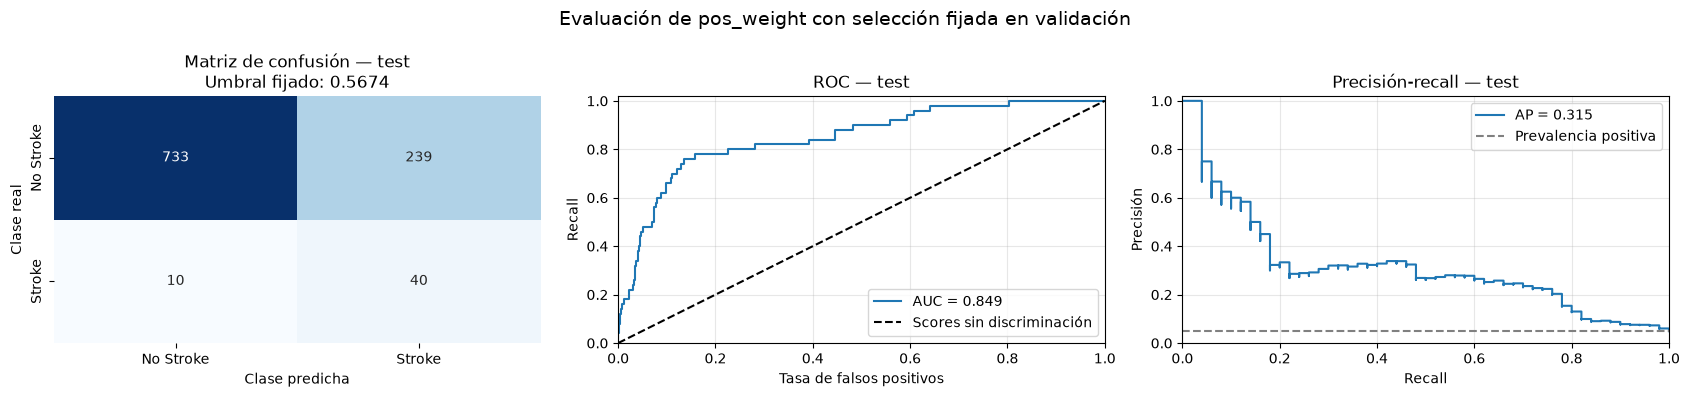

In [133]:
matrix_test = confusion_matrix(labels_test, predictions_test, labels=[0, 1])
fpr_test, tpr_test, _ = roc_curve(labels_test, probabilities_test)
precision_test, recall_test, _ = precision_recall_curve(labels_test, probabilities_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.heatmap(
    matrix_test, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"],
    ax=axes[0],
)
axes[0].set_title(f"Matriz de confusión — test\nUmbral fijado: {umbral_test:.4f}")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")

axes[1].plot(fpr_test, tpr_test, label=f"AUC = {resultados_test['AUC_ROC']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Scores sin discriminación")
axes[1].set(title="ROC — test", xlabel="Tasa de falsos positivos", ylabel="Recall")

axes[2].step(recall_test, precision_test, where="post", label=f"AP = {resultados_test['AP']:.3f}")
axes[2].axhline(labels_test.mean(), color="gray", linestyle="--", label="Prevalencia positiva")
axes[2].set(title="Precisión-recall — test", xlabel="Recall", ylabel="Precisión")
for ax in axes[1:]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(f"Evaluación de {nombre_test} con selección fijada en validación", fontsize=14)
plt.tight_layout()
plt.show()


### 9.3. Resumen de la evaluación final

Para finalizar, se observa la cantidad de positivos detectados y omitidos y el número de falsas alertas. La accuracy se interpreta junto con recall y precisión, debido al desbalance de clases

In [ ]:
print(f"Se detectan {resultados_test['TP']} de {int(labels_test.sum())} casos positivos "
      f"(recall = {resultados_test['Recall']:.3f}); se omiten {resultados_test['FN']}.")
print(f"Se generan {resultados_test['Alertas']} alertas, de las cuales {resultados_test['FP']} "
      f"son falsas (precisión = {resultados_test['Precision']:.3f}).")
print(f"F1 = {resultados_test['F1']:.3f}; F2 = {resultados_test['F2']:.3f}; "
      f"AUC-ROC = {resultados_test['AUC_ROC']:.3f}; AP = {resultados_test['AP']:.3f}.")
print(f"Accuracy = {resultados_test['Accuracy']:.3f}. Como referencia, predecir siempre "
      f"negativo obtiene {1 - labels_test.mean():.3f}, pero no detecta ningún positivo.")
print("Se conservan el modelo y el umbral elegidos en validación; no se realizan ajustes con test.")


Se detectan 40 de 50 casos positivos (recall = 0.800); se omiten 10.
Se generan 279 alertas, de las cuales 239 son falsas (precisión = 0.143).
F1 = 0.243; F2 = 0.418; AUC-ROC = 0.849; AP = 0.315.
Accuracy = 0.756. Como referencia, predecir siempre negativo obtiene 0.951, pero no detecta ningún positivo.
Se conservan el modelo y el umbral elegidos en validación; no se realizan ajustes con test.


> **Pendiente de desarrollo:** Interpretar conjuntamente las métricas y gráficos de test: detecciones, casos omitidos, falsas alertas y diferencias respecto de validación.


## 10. Conclusiones, limitaciones y posibles mejoras

> **Pendiente de desarrollo:** Sintetizar las decisiones y resultados principales. Describir las limitaciones del desempeño, la cantidad de positivos y el alcance de una única partición y semilla; proponer mejoras coherentes con lo observado.
